# Transfer Learning with MobileNetV2

Welcome to this week's assignment, where you'll be using transfer learning on a pre-trained CNN to build an Alpaca/Not Alpaca classifier!

<img src="images/alpaca.png" style="width:300px;height:220px;">

A pre-trained model is a network that's already been trained on a large dataset and saved, which allows you to use it to customize your own model cheaply and efficiently. The one you'll be using, MobileNetV2, was designed to provide fast and computationally efficient performance. It's been pre-trained on ImageNet, a dataset containing over 14 million images and 1000 classes.

By the end of this assignment, you will be able to:

- Create a dataset from a directory
- Preprocess and augment data using the Sequential API
- Adapt a pretrained model to new data and train a classifier using the Functional API and MobileNet
- Fine-tune a classifier's final layers to improve accuracy 

## Table of Content

- [1 - Packages](#1)
    - [1.1 Create the Dataset and Split it into Training and Validation Sets](#1-1)
- [2 - Preprocess and Augment Training Data](#2)
    - [Exercise 1 - data_augmenter](#ex-1)
- [3 - Using MobileNetV2 for Transfer Learning](#3)
    - [3.1 - Inside a MobileNetV2 Convolutional Building Block](#3-1)
    - [3.2 - Layer Freezing with the Functional API](#3-2)
        - [Exercise 2 - alpaca_model](#ex-2)
    - [3.3 - Fine-tuning the Model](#3-3)
        - [Exercise 3](#ex-3)

<a name='1'></a>
## 1 - Packages

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from PIL import Image
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

<a name='1-1'></a>
### 1.1 Create the Dataset and Split it into Training and Validation Sets

When training and evaluating deep learning models in Keras, generating a dataset from image files stored on disk is simple and fast. Call `image_data_set_from_directory()` to read from the directory and create both training and validation datasets. 

If you're specifying a validation split, you'll also need to specify the subset for each portion. Just set the training set to `subset='training'` and the validation set to `subset='validation'`.

You'll also set your seeds to match each other, so your training and validation sets don't overlap. :) 

In [3]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split

#Data_augmentation을 정의하고, data_aug라는 객체를 반환, 
def Data_augmentation():
    data_aug = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]) 
    ])
    return data_aug

data_augment = Data_augmentation()
full_dataset = datasets.ImageFolder(root="dataset/", transform = data_augment)
dataset_size = len(full_dataset)
train_size = int(0.8 * dataset_size)  # = 262
val_size = dataset_size - train_size  # = 65
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = False)
print(len(train_dataset))
print(len(val_dataset))
#dataset.ImageFolder()으로 데이터 경로의 데이터셋을 저장

#train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
#데이터셋을 데이터로더로 로딩

# def data_augmentation():
#     data_aug = transforms.Compose([
#         transforms.Resize((224, 224)),
#         transforms.RandomHorizontalFlip(p=0.5),
#         transforms.ToTensor(),
#         transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
#     ])
#     return data_aug

# data_augmenter = data_augmentation()
# # full_dataset = datasets.ImageFolder(root="dataset/", transform=data_augmenter)

# # 3. 데이터 수 확인 및 train/val split
# dataset_size = len(full_dataset)  # = 327
# train_size = int(0.8 * dataset_size)  # = 262
# val_size = dataset_size - train_size  # = 65

# train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
# train_loader = DataLoader(train_dataset, batch_size = 32, shuffle= True)
# val_loader = DataLoader(val_dataset, batch_size= 32,shuffle = False)

# print(f"Found {dataset_size} files belonging to {len(full_dataset.classes)} classes.")
# print(f"Using {len(train_dataset)} files for training.")
# print(f"Using {len(val_dataset)} files for validation.")


261
66


In [10]:
from torchvision import models
import torch.nn as nn

# # 1. 사전 학습된 MobileNetV2 불러오기
# # all layer 보기, model 보기
# #불러오기
# base_model = models.resnet18(pretrained=True)
# #전체 얼리기
# for p in base_model.parameters():
#     p.requires_grad = False
# #학습 가능한 children 보기
# for name, child in base_model.named_children():
#     print(f"{name}의 {child}")
# #Children 기반으로 얼리기
#     if name in ['layer4','fc']:
#         for param in child.parameters():
#             param.requires_grad = True
# #학습 가능한 parameters 보기
# base_model.fc = nn.Linear(512,1)

def new_resnet_model():
    base_model = models.resnet18(pretrained=True)
    for p in base_model.parameters():
        p.requires_grad = False
    for name, child in base_model.named_children():
        if name in ['layer3','layer4','fc']:
            for param in child.parameters():
                param.requires_grad = True
    base_model.fc = nn.Linear(512,1)
    return base_model

# named_params = list(base_model.named_layers())
# named_childs = list(base_model.named_children())
# train_n_layers = 10
# train_n_child = 2
# for name, params in named_params[-train_n_layers:]:
#     params.requires_grad = True
# for name, params in named_childs[-train_n_child:]:
#     params.requires_grad = True


# named_params = list()

# for name, child in base_model.named_children():
#     if name in ['layer4','fc']:
#         for param in child.parameters():
#             param.requires_grad = True

# base_model.fc = nn.Linear(512,1)


# # base_model = models.mobilenet_v2(pretrained=True)

# # 2. 모든 레이어를 순서대로 나열 (모듈 단위)
# # all_layers = list(base_model.modules())  # 0번부터 시작, 총 212개
# # all_children = list(base_model.children())
# # print(all_children)
# # print(all_layers)

# #fine_tune_at을 정의, param.requires_grad로 setting

# fine_tune_at = 130
# for i, layer in enumerate(all_layers):
#     for param in layer.parameters(recurse=False):  # 현재 모듈의 파라미터만 조작
#         param.requires_grad = (i >= fine_tune_at)

# #class new_alpaca_model 정의

# #
# class new_alpaca_model(nn.Module):
#     def __init__(self):
#         super(new_alpaca_model, self).__init__()
#         self.base_model = base_model
#         self.pool = nn.AdaptiveAvgPool2d((1, 1))  # Equivalent to GlobalAveragePooling2D
#         self.dropout = nn.Dropout(p=0.2)
#         self.classifier = nn.Linear(1280, 1)  # MobileNetV2 마지막 채널 수 = 1280
    
#     def forward(self,x):
#         x = self.base_model.features(x)
#         x = self.pool(x)
#         x = x.view(x.size(0), -1)
#         x = self.dropout(x)
#         x = self.classifier(x)
#         return x


Now let's take a look at some of the images from the training set: 

In [13]:
def train(model, train_loader, val_loader, learning_rate = 1e-4, epochs = 5, device="cpu"):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),lr = learning_rate)
    for ep in range(epochs):
        model.train()
        train_loss = 0
        train_total = 0
        train_correct = 0
        for img, label in train_loader:
            img = img.to(device)
            label = label.float().unsqueeze(1).to(device)  # BCEWithLogitsLoss expects (B, 1)
            predict = model(img)
            optimizer.zero_grad()
            loss = criterion(predict,label)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * img.size(0)

            with torch.no_grad():
                probs = torch.sigmoid(predict)
                preds = (probs > 0.5).float()
                train_correct += (preds == label).sum().item()
                train_total += label.size(0)
        avg_train_loss = train_loss/train_total
        acc = train_correct / train_total
        print(f"Epoch {ep+1}/{epochs} - Loss: {avg_train_loss:.4f}, Accuracy: {acc:.4f}")

        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for img, label in val_loader:
                img = img.to(device)
                label = label.float().unsqueeze(1).to(device)

                predict = model(img)
                loss = criterion(predict, label)
                val_loss += loss.item() * img.size(0)

                probs = torch.sigmoid(predict)
                preds = (probs > 0.5).float()
                val_correct += (preds == label).sum().item()
                val_total += label.size(0)

        avg_val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        print(f"Validation - Loss: {avg_val_loss:.4f}, Accuracy: {val_acc:.4f}")
    
model = new_resnet_model()
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
train(model,train_loader, val_loader,learning_rate=1e-5,epochs=12, device=device)

Epoch 1/12 - Loss: 0.6976, Accuracy: 0.5326
Validation - Loss: 0.7271, Accuracy: 0.5000
Epoch 2/12 - Loss: 0.5840, Accuracy: 0.6590
Validation - Loss: 0.6215, Accuracy: 0.6061
Epoch 3/12 - Loss: 0.5176, Accuracy: 0.7241
Validation - Loss: 0.5681, Accuracy: 0.6364
Epoch 4/12 - Loss: 0.4430, Accuracy: 0.8123
Validation - Loss: 0.5247, Accuracy: 0.7424
Epoch 5/12 - Loss: 0.3939, Accuracy: 0.8659
Validation - Loss: 0.4768, Accuracy: 0.7273
Epoch 6/12 - Loss: 0.3448, Accuracy: 0.8889
Validation - Loss: 0.4378, Accuracy: 0.7727
Epoch 7/12 - Loss: 0.2866, Accuracy: 0.9425
Validation - Loss: 0.4141, Accuracy: 0.7879
Epoch 8/12 - Loss: 0.2532, Accuracy: 0.9579
Validation - Loss: 0.4044, Accuracy: 0.8182
Epoch 9/12 - Loss: 0.2391, Accuracy: 0.9617
Validation - Loss: 0.3824, Accuracy: 0.8333
Epoch 10/12 - Loss: 0.2171, Accuracy: 0.9693
Validation - Loss: 0.3485, Accuracy: 0.8788
Epoch 11/12 - Loss: 0.1827, Accuracy: 0.9808
Validation - Loss: 0.3453, Accuracy: 0.8485
Epoch 12/12 - Loss: 0.1834, Ac

<a name='2'></a>
## 2 - Preprocess and Augment Training Data

You may have encountered `dataset.prefetch` in a previous TensorFlow assignment, as an important extra step in data preprocessing. 

Using `prefetch()` prevents a memory bottleneck that can occur when reading from disk. It sets aside some data and keeps it ready for when it's needed, by creating a source dataset from your input data, applying a transformation to preprocess it, then iterating over the dataset one element at a time. Because the iteration is streaming, the data doesn't need to fit into memory.

You can set the number of elements to prefetch manually, or you can use `tf.data.experimental.AUTOTUNE` to choose the parameters automatically. Autotune prompts `tf.data` to tune that value dynamically at runtime, by tracking the time spent in each operation and feeding those times into an optimization algorithm. The optimization algorithm tries to find the best allocation of its CPU budget across all tunable operations. 

To increase diversity in the training set and help your model learn the data better, it's standard practice to augment the images by transforming them, i.e., randomly flipping and rotating them. Keras' Sequential API offers a straightforward method for these kinds of data augmentations, with built-in, customizable preprocessing layers. These layers are saved with the rest of your model and can be re-used later.  Ahh, so convenient! 

As always, you're invited to read the official docs, which you can find for data augmentation [here](https://www.tensorflow.org/tutorials/images/data_augmentation).


In [ ]:
# AUTOTUNE = tf.data.experimental.AUTOTUNE
# train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

<a name='ex-1'></a>
### Exercise 1 - data_augmenter

Implement a function for data augmentation. Use a `Sequential` keras model composed of 2 layers:
* `RandomFlip('horizontal')`
* `RandomRotation(0.2)`

In [ ]:
# # UNQ_C1
# # GRADED FUNCTION: data_augmenter
# def data_augmenter():
#     '''
#     Create a Sequential model composed of 2 layers
#     Returns:
#         tf.keras.Sequential
#     '''
#     ### START CODE HERE
#     data_augmentation = tf.keras.Sequential()
#     data_augmentation.add(RandomFlip("horizontal"))
#     data_augmentation.add(RandomRotation(0.2))
#     ### END CODE HERE
    
#     return data_augmentation

In [ ]:
# augmenter = data_augmenter()

# assert(augmenter.layers[0].name.startswith('random_flip')), "First layer must be RandomFlip"
# assert augmenter.layers[0].mode == 'horizontal', "RadomFlip parameter must be horizontal"
# assert(augmenter.layers[1].name.startswith('random_rotation')), "Second layer must be RandomRotation"
# assert augmenter.layers[1].factor == 0.2, "Rotation factor must be 0.2"
# print('\033[92mAll tests passed!')


All tests passed!


Take a look at how an image from the training set has been augmented with simple transformations:

From one cute animal, to 9 variations of that cute animal, in three lines of code. Now your model has a lot more to learn from.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


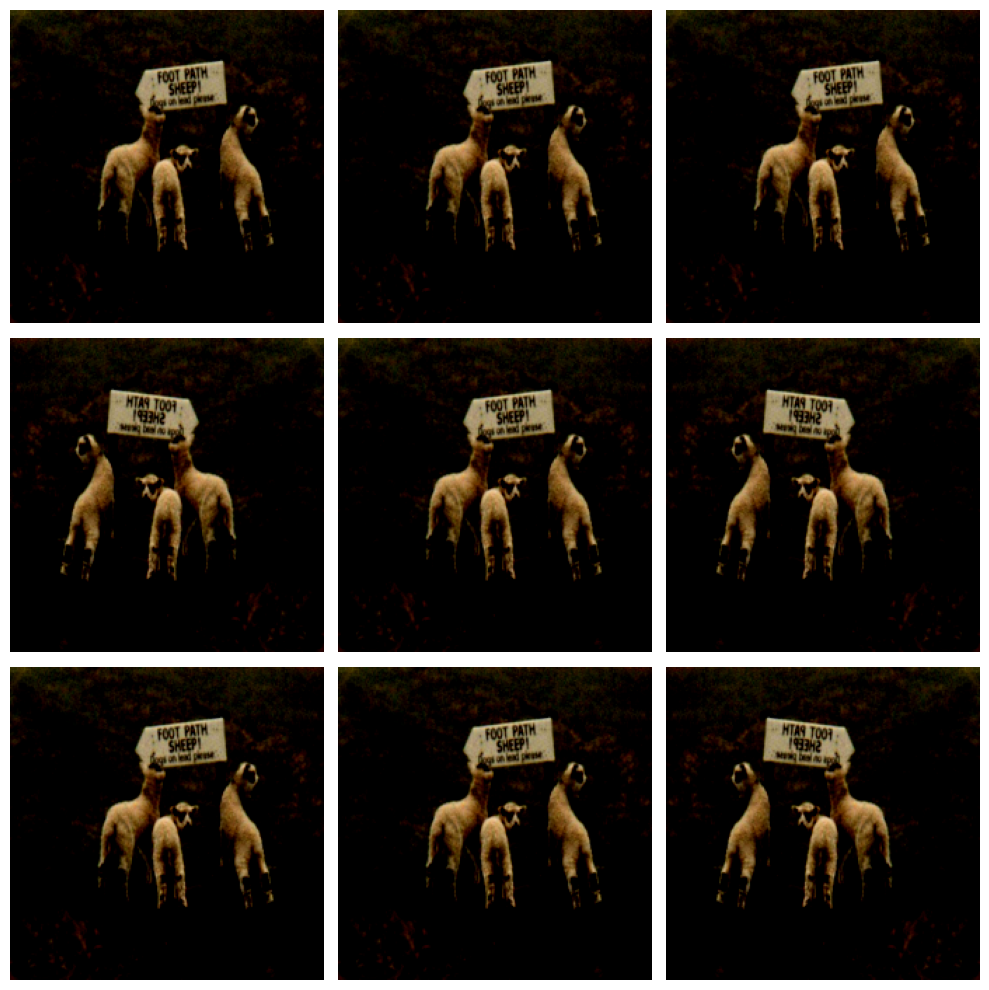

In [5]:
# 3. 하나의 샘플을 선택 (랜덤 or 첫 번째)
img_path, _ = full_dataset.samples[0]  # (PIL image path)
original_image = datasets.folder.default_loader(img_path)  # PIL.Image 열기

# 4. Augmentation 적용 및 시각화
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    transform = data_augmentation()                      # transform 객체 생성
    augmented_image = transform(original_image)   # transform은 PIL 이미지에 직접 적용
    img_np = augmented_image.permute(1, 2, 0).numpy()     # (C, H, W) → (H, W, C)
    plt.imshow(img_np)
    plt.axis("off")
plt.tight_layout()
plt.show()

Next, you'll apply your first tool from the MobileNet application in TensorFlow, to normalize your input. Since you're using a pre-trained model that was trained on the normalization values [-1,1], it's best practice to reuse that standard with tf.keras.applications.mobilenet_v2.preprocess_input.

<font color = 'blue'>

**What you should remember:**

* When calling image_data_set_from_directory(), specify the train/val subsets and match the seeds to prevent overlap
* Use prefetch() to prevent memory bottlenecks when reading from disk
* Give your model more to learn from with simple data augmentations like rotation and flipping.
* When using a pretrained model, it's best to reuse the weights it was trained on.

<a name='3'></a>
## 3 - Using MobileNetV2 for Transfer Learning 

MobileNetV2 was trained on ImageNet and is optimized to run on mobile and other low-power applications. It's 155 layers deep (just in case you felt the urge to plot the model yourself, prepare for a long journey!) and very efficient for object detection and image segmentation tasks, as well as classification tasks like this one. The architecture has three defining characteristics:

*   Depthwise separable convolutions
*   Thin input and output bottlenecks between layers
*   Shortcut connections between bottleneck layers

<a name='3-1'></a>
### 3.1 - Inside a MobileNetV2 Convolutional Building Block

MobileNetV2 uses depthwise separable convolutions as efficient building blocks. Traditional convolutions are often very resource-intensive, and  depthwise separable convolutions are able to reduce the number of trainable parameters and operations and also speed up convolutions in two steps: 

1. The first step calculates an intermediate result by convolving on each of the channels independently. This is the depthwise convolution.

2. In the second step, another convolution merges the outputs of the previous step into one. This gets a single result from a single feature at a time, and then is applied to all the filters in the output layer. This is the pointwise convolution, or: **Shape of the depthwise convolution X Number of filters.**

<img src="images/mobilenetv2.png" style="width:650px;height:450px;">
<caption><center> <u> <font color='purple'> <b>Figure 1</b> </u><font color='purple'>  : <b>MobileNetV2 Architecture</b> <br> This diagram was inspired by the original seen <a href="https://ai.googleblog.com/2018/04/mobilenetv2-next-generation-of-on.html#:~:text=MobileNetV2%20is%20a%20significant%20improvement,object%20detection%20and%20semantic%20segmentation.">here</a>.</center></caption>

Each block consists of an inverted residual structure with a bottleneck at each end. These bottlenecks encode the intermediate inputs and outputs in a low dimensional space, and prevent non-linearities from destroying important information. 

The shortcut connections, which are similar to the ones in traditional residual networks, serve the same purpose of speeding up training and improving predictions. These connections skip over the intermediate convolutions and connect the bottleneck layers. 

Let's try to train your base model using all the layers from the pretrained model. 

Similarly to how you reused the pretrained normalization values MobileNetV2 was trained on, you'll also load the pretrained weights from ImageNet by specifying `weights='imagenet'`. 

In [31]:
from torchvision import models
import torch.nn as nn

# 1. 사전 학습된 MobileNetV2 불러오기
base_model = models.mobilenet_v2(pretrained=True)

# 2. 모든 레이어를 순서대로 나열 (모듈 단위)
all_layers = list(base_model.modules())  # 0번부터 시작, 총 212개
all_children = list(base_model.children())
# print(all_children)
# print(all_layers)
# # print(len(all_layers))
fine_tune_at = 130
for i, layer in enumerate(all_layers):
    for param in layer.parameters(recurse=False):  # 현재 모듈의 파라미터만 조작
        param.requires_grad = (i >= fine_tune_at)
# for i, layer in enumerate(all_layers):
#     trainable = any(p.requires_grad for p in layer.parameters(recurse=False))
    # print(f"{i:3d}: {layer.__class__.__name__} | Trainable: {trainable}")
# print(base_model)
class new_alpaca_model(nn.Module):
    def __init__(self):
        super(new_alpaca_model, self).__init__()
        self.base_model = base_model
        self.pool = nn.AdaptiveAvgPool2d((1, 1))  # Equivalent to GlobalAveragePooling2D
        self.dropout = nn.Dropout(p=0.2)
        self.classifier = nn.Linear(1280, 1)  # MobileNetV2 마지막 채널 수 = 1280
    
    def forward(self,x):
        x = self.base_model.features(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.classifier(x)
        return x
# # 2. input shape은 torchvision에서는 따로 지정하지 않음
# # 대신 모델에 입력되는 이미지 크기는 224x224여야 함 (이미 Resize로 해결됨)

# # 3. 마지막 classifier layer 구조 확인
# print(base_model.classifier)
# summary(base_model, input_size=(1, 3, 160, 160))
# for i, (name, layer) in enumerate(base_model.named_modules()):
#     print(f"{i:3d}: {name} - {layer.__class__.__name__}")
# for param in base_model.features.parameters():
#     param.requires_grad = False
# print("Last layer name:", base_model.classifier[-1])  # 마지막 Linear
# print("Second-to-last:", base_model.classifier[-2])   # Dropout

Print the model summary below to see all the model's layers, the shapes of their outputs, and the total number of parameters, trainable and non-trainable. 

Note the last 2 layers here. They are the so called top layers, and they are responsible of the classification in the model

Notice some of the layers in the summary, like DepthwiseConv2D and SeparableConv2D. These are part of the intermediate expansion layer mentioned earlier.

<font color='blue'>

**What you should remember**:

* MobileNetV2's unique features are: 
  * Depthwise separable convolutions that provide lightweight feature filtering and creation
  * Input and output bottlenecks that preserve important information on either end of the block
* Depthwise separable convolutions deal with both spatial and depth (number of channels) dimensions

In [35]:
import torch.optim as optim

def train(model, train_loader, val_loader, learning_rate = 0.01, epochs = 5, device="cpu"):
    model.to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),lr = learning_rate)
    for ep in range(epochs):
        model.train()
        train_loss = 0
        train_total = 0
        train_correct = 0
        for img, label in train_loader:
            img = img.to(device)
            label = label.float().unsqueeze(1).to(device)  # BCEWithLogitsLoss expects (B, 1)
            predict = model(img)
            optimizer.zero_grad()
            loss = criterion(predict,label)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * img.size(0)

            with torch.no_grad():
                probs = torch.sigmoid(predict)
                preds = (probs > 0.5).float()
                train_correct += (preds == label).sum().item()
                train_total += label.size(0)
        avg_train_loss = train_loss/train_total
        acc = train_correct / train_total
        print(f"Epoch {ep+1}/{epochs} - Loss: {avg_train_loss:.4f}, Accuracy: {acc:.4f}")

        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for img, label in val_loader:
                img = img.to(device)
                label = label.float().unsqueeze(1).to(device)

                predict = model(img)
                loss = criterion(predict, label)
                val_loss += loss.item() * img.size(0)

                probs = torch.sigmoid(predict)
                preds = (probs > 0.5).float()
                val_correct += (preds == label).sum().item()
                val_total += label.size(0)

        avg_val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        print(f"Validation - Loss: {avg_val_loss:.4f}, Accuracy: {val_acc:.4f}")
    
model = new_alpaca_model()
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
train(model,train_loader, val_loader,learning_rate=1e-4,epochs=10, device=device)

Epoch 1/10 - Loss: 0.4888, Accuracy: 0.8161
Validation - Loss: 0.2506, Accuracy: 0.9394
Epoch 2/10 - Loss: 0.2263, Accuracy: 0.9349
Validation - Loss: 0.1791, Accuracy: 0.9242
Epoch 3/10 - Loss: 0.1362, Accuracy: 0.9617
Validation - Loss: 0.1686, Accuracy: 0.9394
Epoch 4/10 - Loss: 0.0717, Accuracy: 1.0000
Validation - Loss: 0.1875, Accuracy: 0.9545
Epoch 5/10 - Loss: 0.0740, Accuracy: 0.9847
Validation - Loss: 0.1912, Accuracy: 0.9394
Epoch 6/10 - Loss: 0.0413, Accuracy: 0.9962
Validation - Loss: 0.1962, Accuracy: 0.9545
Epoch 7/10 - Loss: 0.0316, Accuracy: 1.0000
Validation - Loss: 0.2241, Accuracy: 0.9091
Epoch 8/10 - Loss: 0.0340, Accuracy: 0.9962
Validation - Loss: 0.2003, Accuracy: 0.9394
Epoch 9/10 - Loss: 0.0228, Accuracy: 0.9923
Validation - Loss: 0.1594, Accuracy: 0.9394
Epoch 10/10 - Loss: 0.0231, Accuracy: 0.9962
Validation - Loss: 0.1332, Accuracy: 0.9545


Next, choose the first batch from the tensorflow dataset to use the images, and run it through the MobileNetV2 base model to test out the predictions on some of your images. 

In [8]:
image_batch, label_batch = next(iter(train_loader))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

torch.Size([32, 1000])


In [9]:
#Shows the different label probabilities in one tensor 
label_batch

tensor([0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
        0, 1, 0, 0, 1, 1, 0, 1])

Now decode the predictions made by the model. Earlier, when you printed the shape of the batch, it would have returned (32, 1000). The number 32 refers to the batch size and 1000 refers to the 1000 classes the model was pretrained on. The predictions returned by the base model below follow this format:

First the class number, then a human-readable label, and last the probability of the image belonging to that class. You'll notice that there are two of these returned for each image in the batch - these the top two probabilities returned for that image.

Uh-oh. There's a whole lot of labels here, some of them hilariously wrong, but none of them say "alpaca."

This is because MobileNet pretrained over ImageNet doesn't have the correct labels for alpacas, so when you use the full model, all you get is a bunch of incorrectly classified images.

Fortunately, you can delete the top layer, which contains all the classification labels, and create a new classification layer.

<a name='3-2'></a>
### 3.2 - Layer Freezing with the Functional API

<img src="images/snowalpaca.png" style="width:400px;height:250px;">

In the next sections, you'll see how you can use a pretrained model to modify the classifier task so that it's able to recognize alpacas. You can achieve this in three steps: 

1. Delete the top layer (the classification layer)
    * Set `include_top` in `base_model` as False
2. Add a new classifier layer
    * Train only one layer by freezing the rest of the network
    * As mentioned before, a single neuron is enough to solve a binary classification problem.
3. Freeze the base model and train the newly-created classifier layer
    * Set `base model.trainable=False` to avoid changing the weights and train *only* the new layer
    * Set training in `base_model` to False to avoid keeping track of statistics in the batch norm layer

<a name='ex-2'></a>
### Exercise 2 - alpaca_model

In [9]:
# # UNQ_C2
# # GRADED FUNCTION
# def alpaca_model(image_shape=IMG_SIZE, data_augmentation=data_augmenter()):
#     ''' Define a tf.keras model for binary classification out of the MobileNetV2 model
#     Arguments:
#         image_shape -- Image width and height
#         data_augmentation -- data augmentation function
#     Returns:
#     Returns:
#         tf.keras.model
#     '''
    
class alpaca_model(nn.Module):
    def __init__(self):
        super(alpaca_model, self).__init__()
        self.base_model = models.mobilenet_v2(pretrained=True)
        self.base_model.features.requires_grad_(False)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))  # Equivalent to GlobalAveragePooling2D
        self.dropout = nn.Dropout(p=0.2)
        self.classifier = nn.Linear(1280, 1)  # MobileNetV2 마지막 채널 수 = 1280
    
    def forward(self,x):
        x = self.base_model.features(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.classifier(x)
        return x
    
#     input_shape = image_shape + (3,)
    
#     ### START CODE HERE
    
#     base_model = tf.keras.applications.MobileNetV2(input_shape=input_shape,
#                                                    include_top=False, # <== Important!!!!
#                                                    weights='imagenet') # From imageNet
    
#     # Freeze the base model by making it non trainable
#     base_model.trainable = False
    
#     # create the input layer (Same as the imageNetv2 input size)
#     inputs = tf.keras.Input(shape=input_shape) 
    
#     # apply data augmentation to the inputs
#     x = data_augmentation(inputs)
    
#     # data preprocessing using the same weights the model was trained on
#     # Already Done -> preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
#     x = preprocess_input(x) 
    
#     # set training to False to avoid keeping track of statistics in the batch norm layer
#     x = base_model(x, training=False) 
    
#     # Add the new Binary classification layers
#     # use global avg pooling to summarize the info in each channel
#     x = tfl.GlobalAveragePooling2D()(x) 
#     #include dropout with probability of 0.2 to avoid overfitting
#     x = tfl.Dropout(0.2)(x)
        
#     # create a prediction layer with one neuron (as a classifier only needs one)
#     prediction_layer = tfl.Dense(1)
    
#     ### END CODE HERE
    
#     outputs = prediction_layer(x) 
#     model = tf.keras.Model(inputs, outputs)
    
#     return model

Create your new model using the data_augmentation function defined earlier.

In [11]:
from torchinfo import summary
import torch

model = alpaca_model().to("cpu")  # or to("cuda") if on GPU
summary(model, input_size=(1, 3, 160, 160))


NameError: name 'alpaca_model' is not defined

In [27]:
# from test_utils import summary, comparator

# alpaca_summary = [['InputLayer', [(None, 160, 160, 3)], 0],
#                     ['Sequential', (None, 160, 160, 3), 0],
#                     ['TensorFlowOpLayer', [(None, 160, 160, 3)], 0],
#                     ['TensorFlowOpLayer', [(None, 160, 160, 3)], 0],
#                     ['Functional', (None, 5, 5, 1280), 2257984],
#                     ['GlobalAveragePooling2D', (None, 1280), 0],
#                     ['Dropout', (None, 1280), 0, 0.2],
#                     ['Dense', (None, 1), 1281, 'linear']] #linear is the default activation

# comparator(summary(model2), alpaca_summary)

# for layer in summary(model2):
#     print(layer)
    

The base learning rate has been set for you, so you can go ahead and compile the new model and run it for 5 epochs:

In [ ]:
# base_learning_rate = 0.01
# model2.compile(optimizer=tf.keras.optimizers.Adam(lr=base_learning_rate),
#               loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
#               metrics=['accuracy'])
import torch.optim as optim

def train(model, train_loader, val_loader, learning_rate = 0.01, epochs = 5, device="cpu"):
    model.to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),lr = learning_rate)
    for ep in range(epochs):
        model.train()
        train_loss = 0
        train_total = 0
        train_correct = 0
        for img, label in train_loader:
            img = img.to(device)
            label = label.float().unsqueeze(1).to(device)  # BCEWithLogitsLoss expects (B, 1)
            predict = model(img)
            optimizer.zero_grad()
            loss = criterion(predict,label)
            loss.backward
            optimizer.step()
            train_loss += loss.item() * img.size(0)

            with torch.no_grad():
                probs = torch.sigmoid(predict)
                preds = (probs > 0.5).float()
                train_correct += (preds == label).sum().item()
                train_total += label.size(0)
        avg_train_loss = train_loss/train_total
        acc = train_correct / train_total
        print(f"Epoch {ep+1}/{epochs} - Loss: {avg_train_loss:.4f}, Accuracy: {acc:.4f}")

        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for img, label in val_loader:
                img = img.to(device)
                label = label.float().unsqueeze(1).to(device)

                predict = model(img)
                loss = criterion(predict, label)
                val_loss += loss.item() * img.size(0)

                probs = torch.sigmoid(predict)
                preds = (probs > 0.5).float()
                val_correct += (preds == label).sum().item()
                val_total += label.size(0)

        avg_val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        print(f"Validation - Loss: {avg_val_loss:.4f}, Accuracy: {val_acc:.4f}")




In [12]:
model = alpaca_model()
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
train(model,train_loader, val_loader,learning_rate=0.01,epochs=5, device=device)

/opt/homebrew/Caskroom/miniconda/base/envs/neuro/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/neuro/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5 - Loss: 0.6156, Accuracy: 0.6705
Validation - Loss: 0.3192, Accuracy: 0.8030
Epoch 2/5 - Loss: 0.2891, Accuracy: 0.8582
Validation - Loss: 0.3436, Accuracy: 0.8485
Epoch 3/5 - Loss: 0.2139, Accuracy: 0.9234
Validation - Loss: 0.3179, Accuracy: 0.8939
Epoch 4/5 - Loss: 0.1533, Accuracy: 0.9310
Validation - Loss: 0.2820, Accuracy: 0.8788
Epoch 5/5 - Loss: 0.1572, Accuracy: 0.9310
Validation - Loss: 0.3480, Accuracy: 0.8333


Plot the training and validation accuracy:

In [13]:
acc = [0.] + history.history['accuracy']
val_acc = [0.] + history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

NameError: name 'history' is not defined

In [21]:
class_names

['alpaca', 'not alpaca']

The results are ok, but could be better. Next, try some fine-tuning.

<a name='3-3'></a>
### 3.3 - Fine-tuning the Model

You could try fine-tuning the model by re-running the optimizer in the last layers to improve accuracy. When you use a smaller learning rate, you take smaller steps to adapt it a little more closely to the new data. In transfer learning, the way you achieve this is by unfreezing the layers at the end of the network, and then re-training your model on the final layers with a very low learning rate. Adapting your learning rate to go over these layers in smaller steps can yield more fine details - and higher accuracy.

The intuition for what's happening: when the network is in its earlier stages, it trains on low-level features, like edges. In the later layers, more complex, high-level features like wispy hair or pointy ears begin to emerge. For transfer learning, the low-level features can be kept the same, as they have common features for most images. When you add new data, you generally want the high-level features to adapt to it, which is rather like letting the network learn to detect features more related to your data, such as soft fur or big teeth. 

To achieve this, just unfreeze the final layers and re-run the optimizer with a smaller learning rate, while keeping all the other layers frozen.

Where the final layers actually begin is a bit arbitrary, so feel free to play around with this number a bit. The important takeaway is that the later layers are the part of your network that contain the fine details (pointy ears, hairy tails) that are more specific to your problem.

First, unfreeze the base model by setting `base_model.trainable=True`, set a layer to fine-tune from, then re-freeze all the layers before it. Run it again for another few epochs, and see if your accuracy improved!

In [10]:
base_model.summary()

AttributeError: 'MobileNetV2' object has no attribute 'summary'

<a name='ex-3'></a>
### Exercise 3

In [51]:
# UNQ_C3

base_model.trainable = True
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 126

### START CODE HERE

##### One Way ########
"""
for layer in base_model.layers:
    if layer.name == 'block_16_expand':
        break
    layer.trainable = False
    print('Layer ' + layer.name + ' frozen.')
"""
######## Other Way ######
# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
    #print('Layer ' + layer.name + ' frozen.')
    layer.trainable = None
    
# Define a BinaryCrossentropy loss function. Use from_logits=True
loss_function= tf.keras.losses.BinaryCrossentropy(from_logits=True)
# Define an Adam optimizer with a learning rate of 0.1 * base_learning_rate
optimizer = tf.keras.optimizers.Adam(learning_rate=base_learning_rate*0.1)# 0.001
# Use accuracy as evaluation metric
metrics=['accuracy']

### END CODE HERE

model2.compile(loss=loss_function,
              optimizer = optimizer,
              metrics=metrics)

Number of layers in the base model:  157


In [52]:
assert type(loss_function) == tf.python.keras.losses.BinaryCrossentropy, "Not the correct layer"
assert loss_function.from_logits, "Use from_logits=True"
assert type(optimizer) == tf.keras.optimizers.Adam, "This is not an Adam optimizer"
assert optimizer.lr == base_learning_rate / 10, "Wrong learning rate"
assert metrics[0] == 'accuracy', "Wrong metric"

print('\033[92mAll tests passed!')


All tests passed!


In [53]:
fine_tune_epochs = 5
total_epochs =  initial_epochs + fine_tune_epochs

history_fine = model2.fit(train_dataset,
                         epochs=total_epochs,
                         initial_epoch=history.epoch[-1],
                         validation_data=validation_dataset)

Epoch 5/10
9/9 [==============================] - 8s 835ms/step - loss: 0.2021 - accuracy: 0.9046 - val_loss: 0.0752 - val_accuracy: 0.9692
Epoch 6/10
9/9 [==============================] - 7s 768ms/step - loss: 0.2034 - accuracy: 0.9122 - val_loss: 0.0669 - val_accuracy: 0.9692
Epoch 7/10
9/9 [==============================] - 7s 776ms/step - loss: 0.1845 - accuracy: 0.9198 - val_loss: 0.0664 - val_accuracy: 0.9692
Epoch 8/10
9/9 [==============================] - 7s 768ms/step - loss: 0.1752 - accuracy: 0.9008 - val_loss: 0.0743 - val_accuracy: 0.9692
Epoch 9/10
9/9 [==============================] - 7s 758ms/step - loss: 0.1499 - accuracy: 0.9351 - val_loss: 0.0613 - val_accuracy: 0.9692
Epoch 10/10
9/9 [==============================] - 7s 767ms/step - loss: 0.1719 - accuracy: 0.9351 - val_loss: 0.0655 - val_accuracy: 0.9692


Ahhh, quite an improvement! A little fine-tuning can really go a long way.

In [54]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

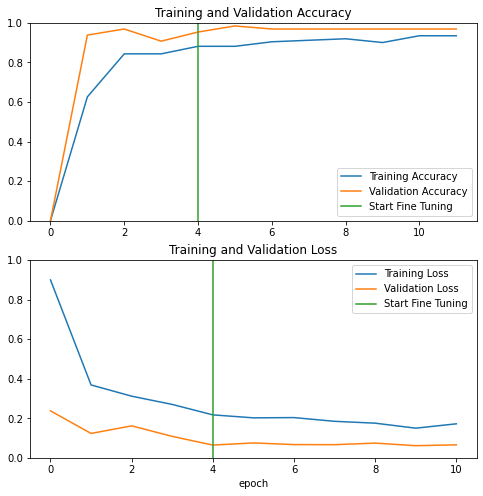

In [55]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

<font color='blue'>

**What you should remember**:

* To adapt the classifier to new data: Delete the top layer, add a new classification layer, and train only on that layer
* When freezing layers, avoid keeping track of statistics (like in the batch normalization layer)
* Fine-tune the final layers of your model to capture high-level details near the end of the network and potentially improve accuracy 

## Congratulations!

You've completed this assignment on transfer learning and fine-tuning. Here's a quick recap of all you just accomplished:

* Created a dataset from a directory
* Augmented data with the Sequential API
* Adapted a pretrained model to new data with the Functional API and MobileNetV2
* Fine-tuned the classifier's final layers and boosted the model's accuracy

That's awesome! 